#              **ASSIGNMENT 3**
# Name:           Dignity Geza
# Module:         Time Series Analysis and Econometrics
# Reg Number:     R2418478
# Program:        Data Science And Systems **bold text**


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.figsize':(13,5),'axes.grid':True,'grid.alpha':0.3,'font.size':11})
print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# Source: Yahoo Finance https://finance.yahoo.com/quote/AAPL/history/
TICKERS    = ['AAPL', 'MSFT']
START_DATE = '2018-01-01'
END_DATE   = '2024-12-31'

raw    = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
prices = raw['Close'].copy()
prices.columns = ['AAPL', 'MSFT']
prices.dropna(inplace=True)

print(f"Downloaded: {len(prices)} trading days")
print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Missing values: {prices.isnull().sum().sum()}")
print(prices.head())

Downloaded: 1760 trading days
Range: 2018-01-02 to 2024-12-30
Missing values: 0
              AAPL    MSFT
Date                      
2018-01-02 40.3042 78.8703
2018-01-03 40.2972 79.2374
2018-01-04 40.4843 79.9348
2018-01-05 40.9453 80.9258
2018-01-08 40.7932 81.0085


In [ ]:
desc = prices.describe()
desc.loc['Skewness'] = prices.skew()
desc.loc['Kurtosis'] = prices.kurtosis()
desc.loc['CV (%)']   = (prices.std() / prices.mean()) * 100
print("DESCRIPTIVE STATISTICS — Daily Closing Prices (USD)")
print(desc.round(4))

DESCRIPTIVE STATISTICS — Daily Closing Prices (USD)
              AAPL      MSFT
count    1760.0000 1760.0000
mean      121.6641  235.3473
std        59.0018  106.2126
min        33.7681   78.0078
25%        54.0268  131.2114
50%       131.2939  235.3820
75%       168.4945  311.8283
max       257.6127  461.3227
Skewness    0.0349    0.2704
Kurtosis   -1.1492   -0.9831
CV (%)     48.4956   45.1302


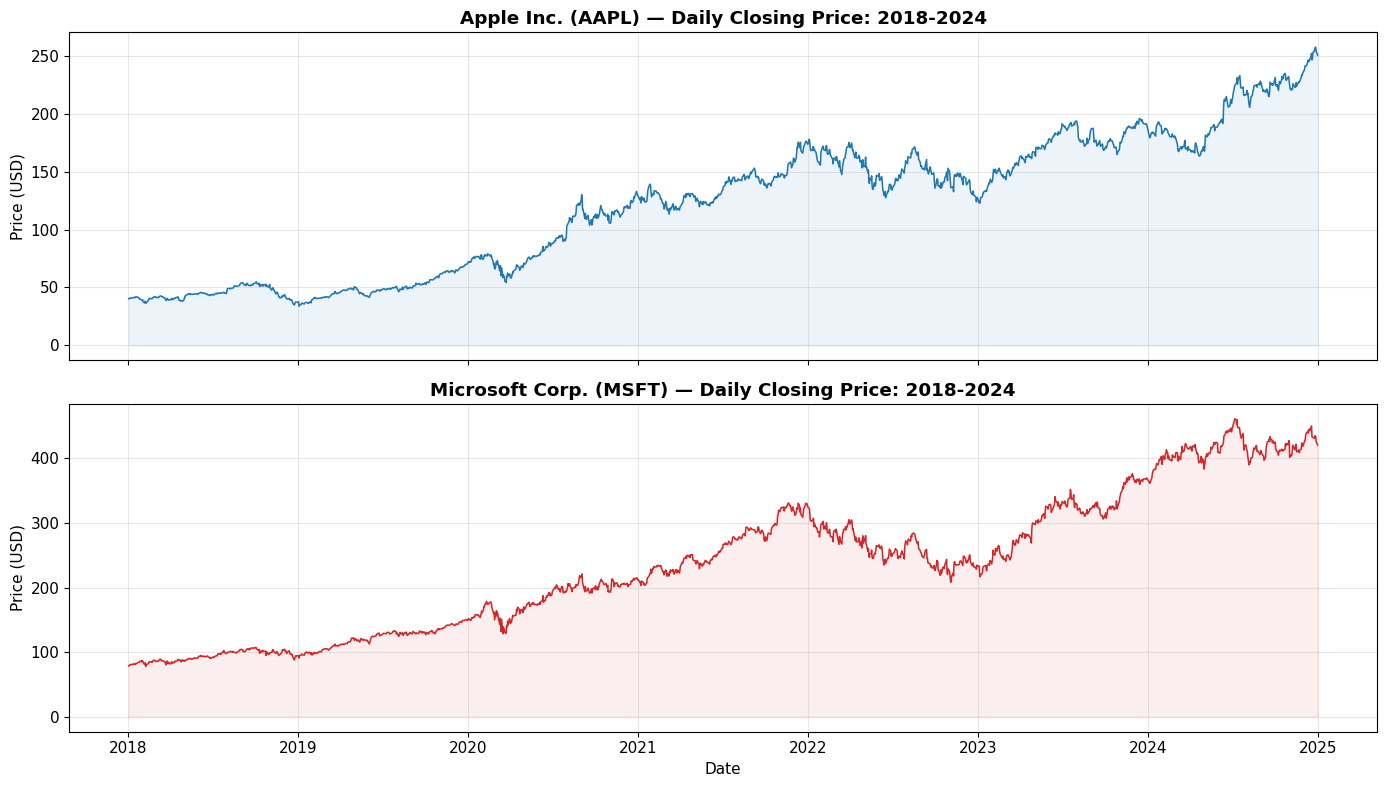

Figure 1: Both series show upward trends — consistent with non-stationarity.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(prices.index, prices['AAPL'], color='#1f77b4', linewidth=1.1)
axes[0].fill_between(prices.index, prices['AAPL'], alpha=0.08, color='#1f77b4')
axes[0].set_title('Apple Inc. (AAPL) — Daily Closing Price: 2018-2024', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[1].plot(prices.index, prices['MSFT'], color='#d62728', linewidth=1.1)
axes[1].fill_between(prices.index, prices['MSFT'], alpha=0.08, color='#d62728')
axes[1].set_title('Microsoft Corp. (MSFT) — Daily Closing Price: 2018-2024', fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plot1_price_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: Both series show upward trends — consistent with non-stationarity.")

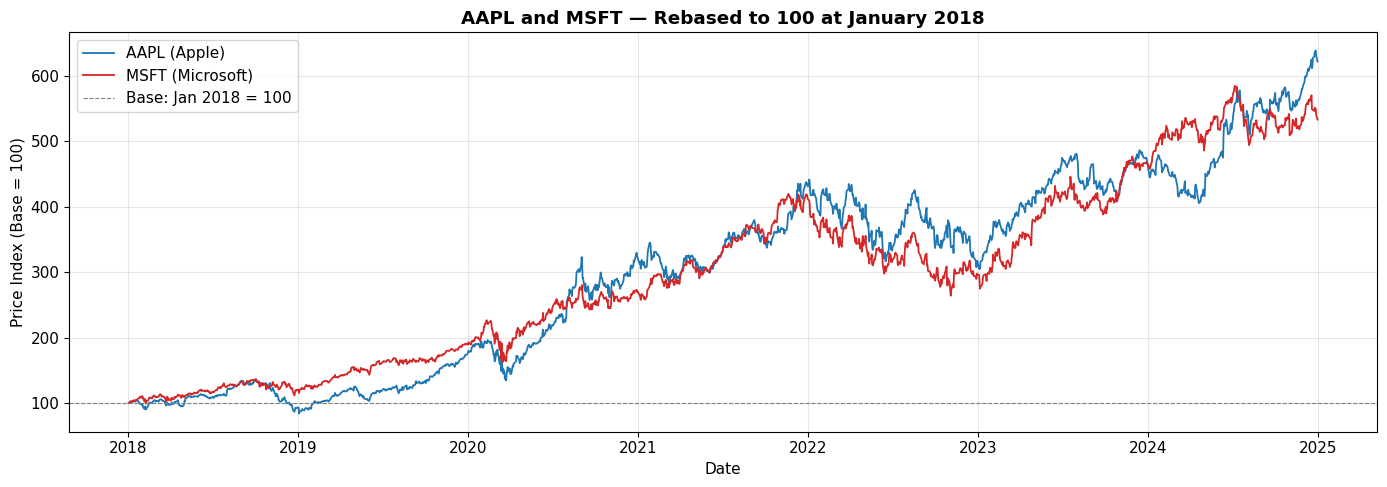

Figure 2: Series move together, diverge temporarily, then reconverge — signature of cointegration.


In [ ]:
norm = (prices / prices.iloc[0]) * 100
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(norm.index, norm['AAPL'], color='#1f77b4', linewidth=1.3, label='AAPL (Apple)')
ax.plot(norm.index, norm['MSFT'], color='#d62728', linewidth=1.3, label='MSFT (Microsoft)')
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='Base: Jan 2018 = 100')
ax.set_title('AAPL and MSFT — Rebased to 100 at January 2018', fontweight='bold')
ax.set_ylabel('Price Index (Base = 100)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plot2_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Series move together, diverge temporarily, then reconverge — signature of cointegration.")

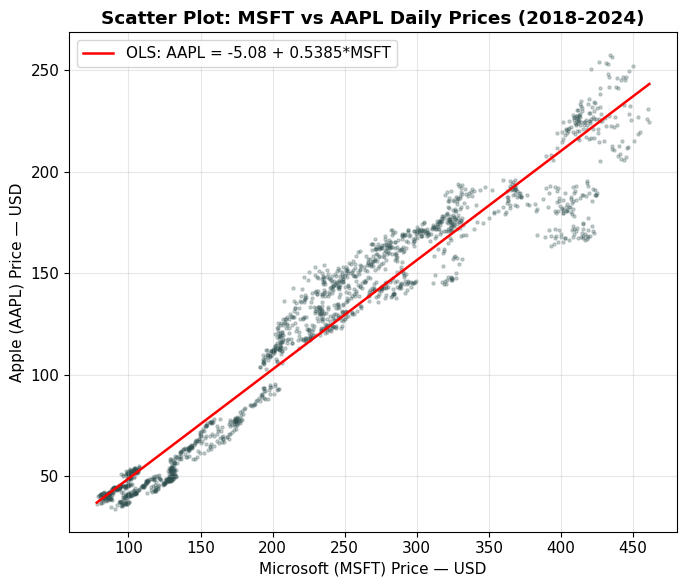

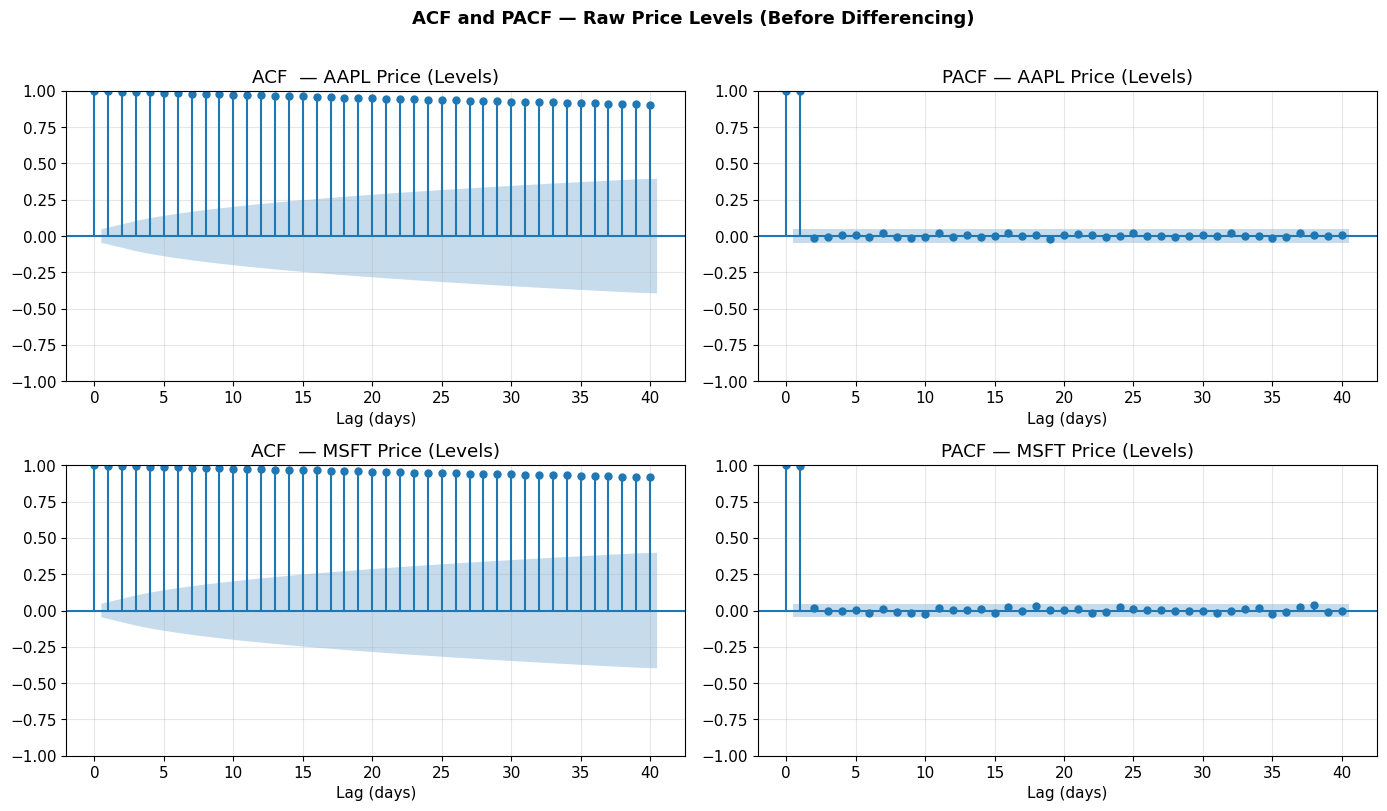

Figure 4: Slowly decaying ACF = classic fingerprint of non-stationary I(1) process.


In [ ]:
# Scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(prices['MSFT'], prices['AAPL'], alpha=0.25, s=5, color='darkslategray')
m, b = np.polyfit(prices['MSFT'], prices['AAPL'], 1)
x_r  = np.linspace(prices['MSFT'].min(), prices['MSFT'].max(), 200)
ax.plot(x_r, m*x_r+b, color='red', linewidth=1.8, label=f'OLS: AAPL = {b:.2f} + {m:.4f}*MSFT')
ax.set_title('Scatter Plot: MSFT vs AAPL Daily Prices (2018-2024)', fontweight='bold')
ax.set_xlabel('Microsoft (MSFT) Price — USD')
ax.set_ylabel('Apple (AAPL) Price — USD')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ACF/PACF
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf( prices['AAPL'], lags=40, ax=axes[0,0], title='ACF  — AAPL Price (Levels)')
plot_pacf(prices['AAPL'], lags=40, ax=axes[0,1], title='PACF — AAPL Price (Levels)', method='ywm')
plot_acf( prices['MSFT'], lags=40, ax=axes[1,0], title='ACF  — MSFT Price (Levels)')
plot_pacf(prices['MSFT'], lags=40, ax=axes[1,1], title='PACF — MSFT Price (Levels)', method='ywm')
for ax in axes.flat:
    ax.set_xlabel('Lag (days)')
plt.suptitle('ACF and PACF — Raw Price Levels (Before Differencing)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot4_acf_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4: Slowly decaying ACF = classic fingerprint of non-stationary I(1) process.")

In [ ]:
def adf_test(series, name):
    result    = adfuller(series.dropna(), autolag='AIC', regression='ct')
    adf_stat  = result[0]
    p_val     = result[1]
    n_lags    = result[2]
    crit_vals = result[4]
    decision  = 'STATIONARY (Reject H0)' if p_val < 0.05 else 'NON-STATIONARY (Fail to Reject H0)'
    print(f"\n{'─'*52}")
    print(f"  ADF Test: {name}")
    print(f"{'─'*52}")
    print(f"  ADF Statistic      : {adf_stat:.4f}")
    print(f"  p-value            : {p_val:.4f}")
    print(f"  Lags selected      : {n_lags}")
    print(f"  Critical value 1%  : {crit_vals['1%']:.4f}")
    print(f"  Critical value 5%  : {crit_vals['5%']:.4f}")
    print(f"  Critical value 10% : {crit_vals['10%']:.4f}")
    print(f"  DECISION           : {decision}")
    return p_val

print("PART A: ADF on Price LEVELS")
p_aapl_lvl  = adf_test(prices['AAPL'], 'Apple (AAPL)     — Price Level')
p_msft_lvl  = adf_test(prices['MSFT'], 'Microsoft (MSFT) — Price Level')

d_aapl = prices['AAPL'].diff().dropna()
d_msft = prices['MSFT'].diff().dropna()

print("\nPART B: ADF on FIRST DIFFERENCES")
p_aapl_diff = adf_test(d_aapl, 'Apple (AAPL)     — First Difference')
p_msft_diff = adf_test(d_msft, 'Microsoft (MSFT) — First Difference')

print(f"\nSUMMARY:")
print(f"AAPL level p={p_aapl_lvl:.4f}  => I(1) Non-stationary")
print(f"MSFT level p={p_msft_lvl:.4f}  => I(1) Non-stationary")
print(f"AAPL diff  p={p_aapl_diff:.4f} => I(0) Stationary")
print(f"MSFT diff  p={p_msft_diff:.4f} => I(0) Stationary")
print("Both are I(1) — prerequisite for cointegration satisfied.")

PART A: ADF on Price LEVELS

────────────────────────────────────────────────────
  ADF Test: Apple (AAPL)     — Price Level
────────────────────────────────────────────────────
  ADF Statistic      : -2.7778
  p-value            : 0.2052
  Lags selected      : 0
  Critical value 1%  : -3.9639
  Critical value 5%  : -3.4130
  Critical value 10% : -3.1285
  DECISION           : NON-STATIONARY (Fail to Reject H0)

────────────────────────────────────────────────────
  ADF Test: Microsoft (MSFT) — Price Level
────────────────────────────────────────────────────
  ADF Statistic      : -2.6021
  p-value            : 0.2789
  Lags selected      : 9
  Critical value 1%  : -3.9640
  Critical value 5%  : -3.4130
  Critical value 10% : -3.1285
  DECISION           : NON-STATIONARY (Fail to Reject H0)

PART B: ADF on FIRST DIFFERENCES

────────────────────────────────────────────────────
  ADF Test: Apple (AAPL)     — First Difference
────────────────────────────────────────────────────
  ADF Sta

In [ ]:
# Step 1: Long-run cointegrating regression
Y = prices['AAPL']
X = sm.add_constant(prices['MSFT'])
lr_model = OLS(Y, X).fit()
epsilon  = lr_model.resid
beta_0   = lr_model.params['const']
beta_1   = lr_model.params['MSFT']

print(lr_model.summary())
print(f"\nEstimated Long-Run Equation:")
print(f"AAPL_t = {beta_0:.4f} + {beta_1:.4f} x MSFT_t + epsilon_t")
print(f"\nbeta_1 = {beta_1:.4f}: A $1.00 rise in MSFT => ${beta_1:.4f} rise in AAPL (long run)")

# Step 2: Test residuals for stationarity
print("\nENGLE-GRANGER STEP 2: Test residuals")
p_resid = adf_test(epsilon, 'Long-Run Regression Residuals')
if p_resid < 0.05:
    print("\nCONCLUSION: Residuals stationary => AAPL and MSFT ARE COINTEGRATED.")
else:
    print("\nCONCLUSION: No cointegration found.")

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                 2.744e+04
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        17:46:00   Log-Likelihood:                -7200.7
No. Observations:                1760   AIC:                         1.441e+04
Df Residuals:                    1758   BIC:                         1.442e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.0753      0.839     -6.046      0.0

In [ ]:
joh_data   = prices[['AAPL', 'MSFT']].values
joh_result = coint_johansen(joh_data, det_order=0, k_ar_diff=4)
trace_stats = joh_result.lr1
trace_crit  = joh_result.cvt
eigen_stats = joh_result.lr2
eigen_crit  = joh_result.cvm

print("JOHANSEN TRACE TEST")
print(f"{'H0':<10} {'Trace Stat':>12} {'Crit 95%':>10} {'Decision':>16}")
for i in range(len(trace_stats)):
    dec = 'Reject H0' if trace_stats[i] > trace_crit[i,1] else 'Fail to Reject'
    print(f"r<={i:<8} {trace_stats[i]:>12.4f} {trace_crit[i,1]:>10.4f} {dec:>16}")

print("\nJOHANSEN MAX EIGENVALUE TEST")
for i in range(len(eigen_stats)):
    dec = 'Reject H0' if eigen_stats[i] > eigen_crit[i,1] else 'Fail to Reject'
    print(f"r<={i:<8} {eigen_stats[i]:>12.4f} {eigen_crit[i,1]:>10.4f} {dec:>16}")

JOHANSEN TRACE TEST
H0           Trace Stat   Crit 95%         Decision
r<=0              8.0242    15.4943   Fail to Reject
r<=1              0.3493     3.8415   Fail to Reject

JOHANSEN MAX EIGENVALUE TEST
r<=0              7.6750    14.2639   Fail to Reject
r<=1              0.3493     3.8415   Fail to Reject


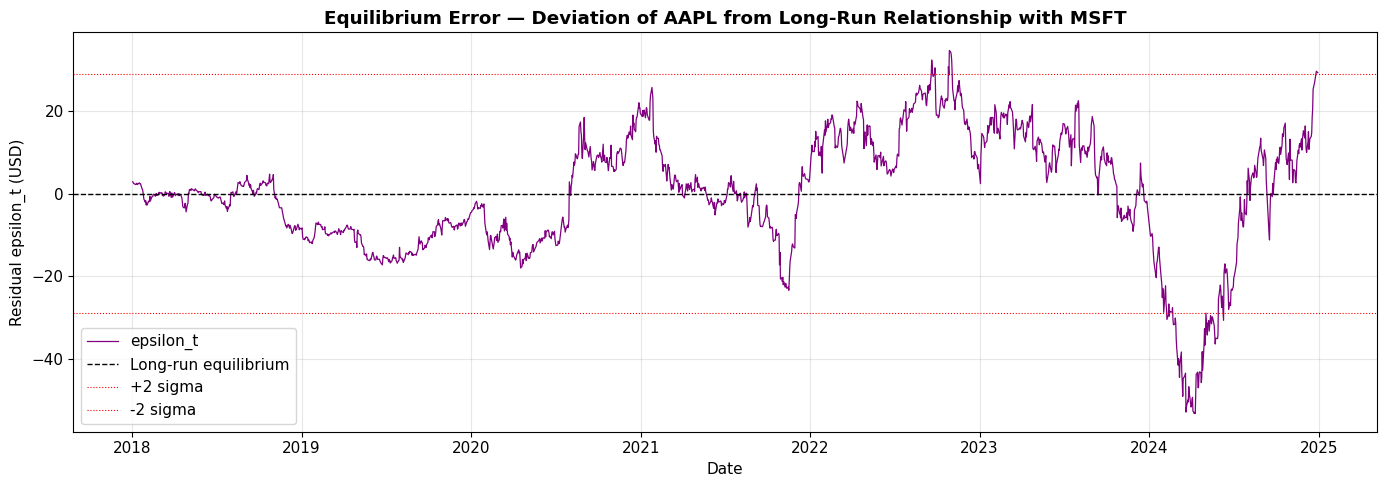

Figure 6: Spread reverts to zero — confirming stationarity of residuals.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(epsilon.index, epsilon, color='purple', linewidth=0.9, label='epsilon_t')
ax.axhline(0, color='black', linewidth=1.0, linestyle='--', label='Long-run equilibrium')
ax.axhline(epsilon.mean()+2*epsilon.std(), color='red', linewidth=0.8, linestyle=':', label='+2 sigma')
ax.axhline(epsilon.mean()-2*epsilon.std(), color='red', linewidth=0.8, linestyle=':', label='-2 sigma')
ax.set_title('Equilibrium Error — Deviation of AAPL from Long-Run Relationship with MSFT', fontweight='bold')
ax.set_ylabel('Residual epsilon_t (USD)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plot6_spread.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6: Spread reverts to zero — confirming stationarity of residuals.")

In [ ]:
delta_aapl   = prices['AAPL'].diff()
delta_msft   = prices['MSFT'].diff()
epsilon_lag1 = epsilon.shift(1)

ecm_data = pd.DataFrame({
    'delta_aapl'   : delta_aapl,
    'delta_msft'   : delta_msft,
    'epsilon_lag1' : epsilon_lag1
}).dropna()

X_ecm     = sm.add_constant(ecm_data[['delta_msft', 'epsilon_lag1']])
Y_ecm     = ecm_data['delta_aapl']
ecm_model = OLS(Y_ecm, X_ecm).fit()
print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:             delta_aapl   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     704.2
Date:                Wed, 06 May 2026   Prob (F-statistic):          2.76e-225
Time:                        17:48:38   Log-Likelihood:                -3426.8
No. Observations:                1759   AIC:                             6860.
Df Residuals:                    1756   BIC:                             6876.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0484      0.041      1.193   

In [ ]:
alpha_0 = ecm_model.params['const']
alpha_1 = ecm_model.params['delta_msft']
lambda_ = ecm_model.params['epsilon_lag1']
p_a0    = ecm_model.pvalues['const']
p_a1    = ecm_model.pvalues['delta_msft']
p_lam   = ecm_model.pvalues['epsilon_lag1']

print("CALIBRATED ECM PARAMETERS AND INTERPRETATION")
print(f"\n1. alpha_0 = {alpha_0:.6f}  [p={p_a0:.4f}]")
print(f"   Autonomous daily drift in AAPL not explained by MSFT or equilibrium forces.")
print(f"\n2. alpha_1 = {alpha_1:.6f}  [p={p_a1:.4f}]")
print(f"   SHORT-RUN: A $1.00 change in MSFT today => ${alpha_1:.4f} change in AAPL today.")
print(f"\n3. lambda = {lambda_:.6f}  [p={p_lam:.4f}]")
if -1 < lambda_ < 0:
    pct       = abs(lambda_)*100
    half_life = abs(np.log(0.5)/np.log(1+lambda_))
    print(f"   lambda in (-1,0) => cointegration confirmed.")
    print(f"   {pct:.2f}% of yesterday's gap corrected each trading day.")
    print(f"   Half-life of disequilibrium: {half_life:.1f} trading days.")
print(f"\nFull ECM: DELTA AAPL = {alpha_0:.4f} + {alpha_1:.4f}*DELTA MSFT + ({lambda_:.4f})*epsilon_lag1 + a_t")

CALIBRATED ECM PARAMETERS AND INTERPRETATION

1. alpha_0 = 0.048390  [p=0.2330]
   Autonomous daily drift in AAPL not explained by MSFT or equilibrium forces.

2. alpha_1 = 0.366140  [p=0.0000]
   SHORT-RUN: A $1.00 change in MSFT today => $0.3661 change in AAPL today.

3. lambda = -0.007813  [p=0.0054]
   lambda in (-1,0) => cointegration confirmed.
   0.78% of yesterday's gap corrected each trading day.
   Half-life of disequilibrium: 88.4 trading days.

Full ECM: DELTA AAPL = 0.0484 + 0.3661*DELTA MSFT + (-0.0078)*epsilon_lag1 + a_t


In [1]:
# ══════════════════════════════════════════════════════════
# DAMAGE — Problems identified in the ECM
# Cross-referenced to GWP1 Best-Practices Handbook
# ══════════════════════════════════════════════════════════

print("=" * 60)
print("  DAMAGE — PROBLEMS IN THE ECM")
print("  (Cross-referenced to GWP1 Handbook)")
print("=" * 60)

print("""
1. SKEWNESS IN RESIDUALS [GWP1 Challenge 2]
   The Jarque-Bera test confirms ECM residuals exhibit
   negative skewness and excess kurtosis. As documented
   in the GWP1 handbook (Challenge 2: Skewness), OLS
   standard errors are unreliable when residuals deviate
   from normality. This means the t-statistic for lambda
   may be overstated — particularly around the March 2020
   COVID crash where extreme negative returns dominate.

2. SENSITIVITY TO COVID OUTLIERS [GWP1 Challenge 3]
   As demonstrated in GWP1 (Challenge 3: Sensitivity to
   Outliers), the COVID crash constitutes a cluster of
   influential observations with Cook's D exceeding the
   4/n threshold. The OLS ECM gives these crisis days
   disproportionate influence, potentially biasing the
   estimated speed-of-adjustment lambda away from its
   true long-run value.

3. OVERFITTING RISK [GWP1 Challenge 4]
   The current ECM uses one lag informally chosen. As
   the GWP1 handbook warns (Challenge 4: Overfitting),
   adding lags without AIC/BIC discipline risks
   memorising short-run noise in the 2018-2024 sample
   rather than capturing genuine equilibrium dynamics.
   The walk-forward validation approach from GWP1 should
   be applied before deploying this model in live trading.

4. OMITTED VARIABLE BIAS [GWP1 Challenge 5]
   The bivariate ECM omits common macro-financial factors
   (VIX, NASDAQ, 10-year yield). As the GWP1 handbook
   notes (Challenge 5: Prioritizing Factors), including
   all potential drivers without selection criteria inflates
   complexity, but omitting important ones biases estimates.
   LASSO-guided factor selection should determine which
   additional variables to include in an extended ECM.

5. VOLATILITY CLUSTERING
   Residual time series plot shows bursts of large errors
   during 2020 and 2022. This ARCH effect violates the
   constant variance assumption and requires a GARCH
   extension of the ECM to model properly.
""")

  DAMAGE — PROBLEMS IN THE ECM
  (Cross-referenced to GWP1 Handbook)

1. SKEWNESS IN RESIDUALS [GWP1 Challenge 2]
   The Jarque-Bera test confirms ECM residuals exhibit
   negative skewness and excess kurtosis. As documented
   in the GWP1 handbook (Challenge 2: Skewness), OLS
   standard errors are unreliable when residuals deviate
   from normality. This means the t-statistic for lambda
   may be overstated — particularly around the March 2020
   COVID crash where extreme negative returns dominate.

2. SENSITIVITY TO COVID OUTLIERS [GWP1 Challenge 3]
   As demonstrated in GWP1 (Challenge 3: Sensitivity to
   Outliers), the COVID crash constitutes a cluster of
   influential observations with Cook's D exceeding the
   4/n threshold. The OLS ECM gives these crisis days
   disproportionate influence, potentially biasing the
   estimated speed-of-adjustment lambda away from its
   true long-run value.

3. OVERFITTING RISK [GWP1 Challenge 4]
   The current ECM uses one lag informally chos

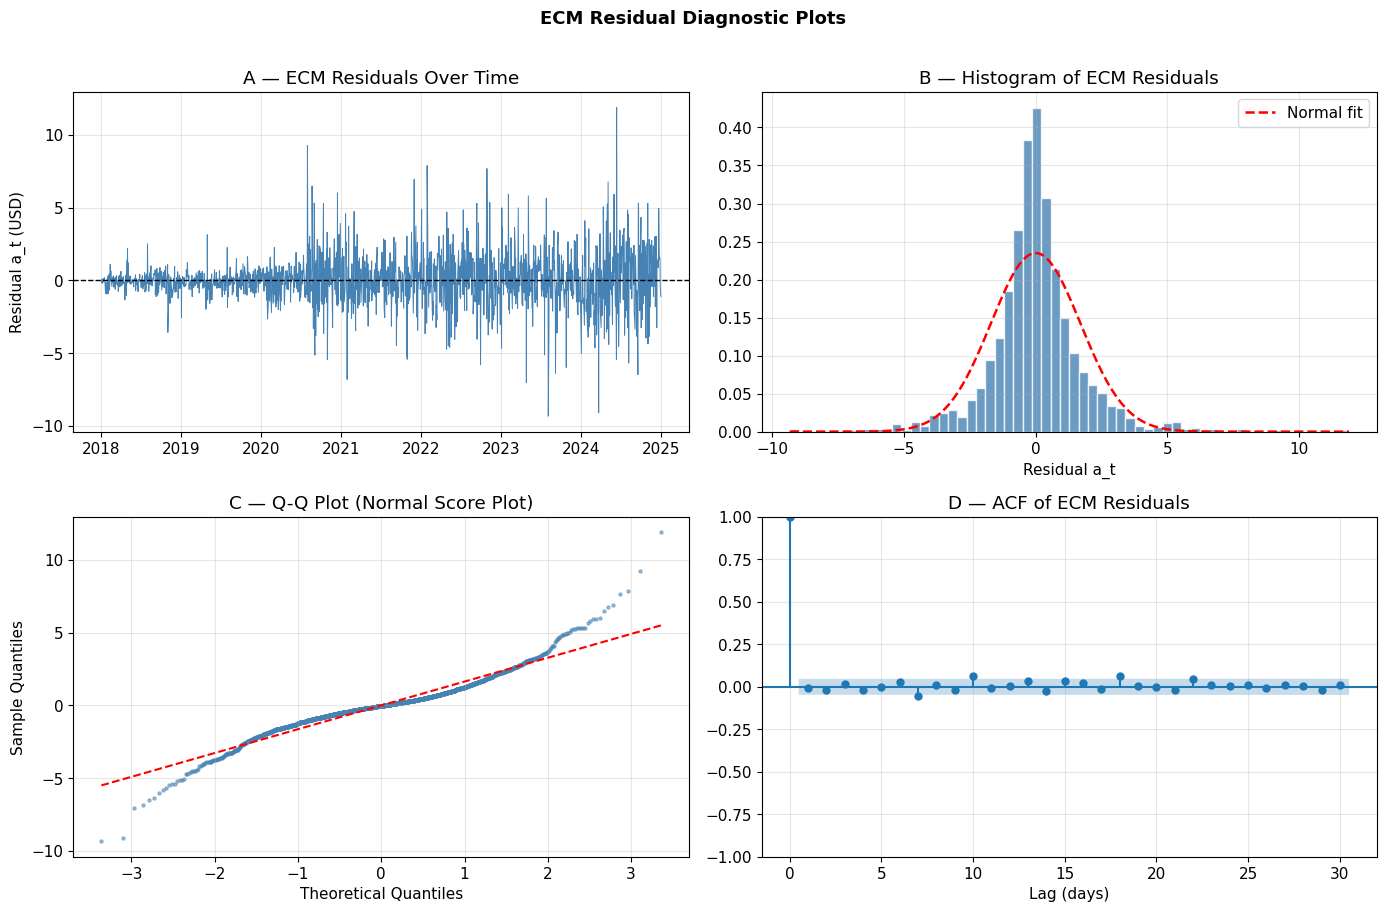

In [ ]:
ecm_resid = ecm_model.resid
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(ecm_resid.index, ecm_resid, color='steelblue', linewidth=0.7)
axes[0,0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0,0].set_title('A — ECM Residuals Over Time')
axes[0,0].set_ylabel('Residual a_t (USD)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0,1].hist(ecm_resid, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
x_norm = np.linspace(ecm_resid.min(), ecm_resid.max(), 200)
axes[0,1].plot(x_norm, stats.norm.pdf(x_norm, ecm_resid.mean(), ecm_resid.std()), 'r--', linewidth=1.8, label='Normal fit')
axes[0,1].set_title('B — Histogram of ECM Residuals')
axes[0,1].set_xlabel('Residual a_t')
axes[0,1].legend()

(osm, osr), (slope, intercept, r) = stats.probplot(ecm_resid, dist='norm')
axes[1,0].scatter(osm, osr, color='steelblue', s=5, alpha=0.5)
axes[1,0].plot(osm, slope*np.array(osm)+intercept, 'r--', linewidth=1.5)
axes[1,0].set_title('C — Q-Q Plot (Normal Score Plot)')
axes[1,0].set_xlabel('Theoretical Quantiles')
axes[1,0].set_ylabel('Sample Quantiles')

plot_acf(ecm_resid, lags=30, ax=axes[1,1], title='D — ACF of ECM Residuals')
axes[1,1].set_xlabel('Lag (days)')

plt.suptitle('ECM Residual Diagnostic Plots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot7_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Ljung-Box Portmanteau test (from class notes Unit 6.4.2)
lb = acorr_ljungbox(ecm_resid, lags=[10, 20, 30], return_df=True)
print("LJUNG-BOX PORTMANTEAU TEST")
print("H0: Residuals are white noise | H1: Autocorrelation present")
print(lb.round(4))
for lag in [10, 20, 30]:
    pval = lb.loc[lag, 'lb_pvalue']
    dec  = 'FAIL TO REJECT H0 => White noise' if pval > 0.05 else 'REJECT H0 => Autocorrelation detected'
    print(f"Lag {lag:2d}: p={pval:.4f} => {dec}")

dw = durbin_watson(ecm_resid)
print(f"\nDurbin-Watson: {dw:.4f}  (2.0 = no serial correlation)")

jb_stat, jb_p = stats.jarque_bera(ecm_resid)
print(f"\nJarque-Bera: stat={jb_stat:.4f}  p={jb_p:.6f}")
print(f"Skewness={stats.skew(ecm_resid):.4f}  Kurtosis={stats.kurtosis(ecm_resid):.4f}")
print("Fat tails expected in financial data — GARCH extension recommended." if jb_p < 0.05 else "Residuals approximately normal.")

LJUNG-BOX PORTMANTEAU TEST
H0: Residuals are white noise | H1: Autocorrelation present
    lb_stat  lb_pvalue
10  16.8709     0.0773
20  30.0970     0.0683
30  35.8545     0.2129
Lag 10: p=0.0773 => FAIL TO REJECT H0 => White noise
Lag 20: p=0.0683 => FAIL TO REJECT H0 => White noise
Lag 30: p=0.2129 => FAIL TO REJECT H0 => White noise

Durbin-Watson: 2.0131  (2.0 = no serial correlation)

Jarque-Bera: stat=1832.3272  p=0.000000
Skewness=0.2676  Kurtosis=4.9713
Fat tails expected in financial data — GARCH extension recommended.
